In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import torch, numpy as np
from pathlib import Path
from config import config

In [3]:
from run_models import run_VAE, run_KMeans
from utils.common import extract_latents

d:\MSc\3. Spring 2026\CSE715\Project\vae-audio-clustering\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [5]:
root = Path("../..")

### check that config.MODEL_TYPE = "basic"

In [6]:
config.MODEL_TYPE

'basic'

In [7]:
basic_vae, latent_dim, train_loader, test_loader, vae_history, study = run_VAE(model_type="basic", plot_dir_name="easy_1_basic_vae", root=root) #type: ignore

d:\MSc\3. Spring 2026\CSE715\Project\vae-audio-clustering\venv\Lib\site-packages\optuna\_experimental.py:33: ExperimentalWarning: Argument ``multivariate`` is an experimental feature. The interface can change in the future.
  optuna_warn(
[I 2026-04-10 08:41:49,613] A new study created in memory with name: Basic VAE Tuning
  0%|          | 0/5 [00:00<?, ?it/s]D:\MSc\3. Spring 2026\CSE715\Project\vae-audio-clustering\src\utils\common.py:42: UserWarning: Using a target size (torch.Size([32, 1, 64, 91])) that is different to the input size (torch.Size([32, 64, 91])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  recon = F.mse_loss(x_hat, x, reduction="sum")
D:\MSc\3. Spring 2026\CSE715\Project\vae-audio-clustering\src\utils\common.py:42: UserWarning: Using a target size (torch.Size([19, 1, 64, 91])) that is different to the input size (torch.Size([19, 64, 91])). This will likely lead to incorrect results due to broadcasting. Pleas

--------------------------------------------------
Epoch 1 / 5
Metric       | Train        | Test        
--------------------------------------------------
Total Loss   | 10796.4219   | 5203.1242   
Recon        | 10785.3606   | 5191.3590   
KL Div       | 55.3063      | 58.8261     
--------------------------------------------------

--------------------------------------------------
Epoch 2 / 5
Metric       | Train        | Test        
--------------------------------------------------
Total Loss   | 4530.4341    | 4374.5694   
Recon        | 4520.1188    | 4365.2198   
KL Div       | 51.5766      | 46.7480     
--------------------------------------------------

--------------------------------------------------
Epoch 3 / 5
Metric       | Train        | Test        
--------------------------------------------------
Total Loss   | 4292.5614    | 4398.8086   
Recon        | 4282.0703    | 4388.8461   
KL Div       | 52.4554      | 49.8129     
--------------------------------------

  0%|          | 0/5 [00:36<?, ?it/s]

--------------------------------------------------
Epoch 5 / 5
Metric       | Train        | Test        
--------------------------------------------------
Total Loss   | 4228.2205    | 4193.0165   
Recon        | 4219.0264    | 4182.6957   
KL Div       | 45.9703      | 51.6039     
--------------------------------------------------

[I 2026-04-10 08:42:26,302] Trial 0 finished with value: 2530.258977982039 and parameters: {'HIDDEN_DIM_1': 1024, 'HIDDEN_DIM_2': 128, 'LATENT_DIM': 32, 'LR': 0.0005105903209394755, 'BATCH_SIZE': 32, 'BETA': 5.0}. Best is trial 0 with value: 2530.258977982039.


Best trial: 0. Best value: 2530.26:  20%|██        | 1/5 [00:36<02:27, 36.87s/it]D:\MSc\3. Spring 2026\CSE715\Project\vae-audio-clustering\src\utils\common.py:42: UserWarning: Using a target size (torch.Size([64, 1, 64, 91])) that is different to the input size (torch.Size([64, 64, 91])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  recon = F.mse_loss(x_hat, x, reduction="sum")
D:\MSc\3. Spring 2026\CSE715\Project\vae-audio-clustering\src\utils\common.py:42: UserWarning: Using a target size (torch.Size([37, 1, 64, 91])) that is different to the input size (torch.Size([37, 64, 91])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  recon = F.mse_loss(x_hat, x, reduction="sum")


...

--------------------------------------------------
Epoch 5 / 5
Metric       | Train        | Test        
--------------------------------------------------
Total Loss   | 2198.4982    | 2088.0994   
Recon        | 2184.4573    | 2073.1902   
KL Div       | 70.2046      | 74.5461     
--------------------------------------------------

[I 2026-04-10 08:43:08,831] Trial 4 finished with value: 1273.7325326192008 and parameters: {'HIDDEN_DIM_1': 1024, 'HIDDEN_DIM_2': 256, 'LATENT_DIM': 64, 'LR': 0.00042004723167022017, 'BATCH_SIZE': 16, 'BETA': 4.0}. Best is trial 4 with value: 1273.7325326192008.


Best trial: 4. Best value: 1273.73: 100%|██████████| 5/5 [01:19<00:00, 15.88s/it]


..\..\results\trials\easy_1_basic_vae\plots
Saved: ..\..\results\trials\easy_1_basic_vae\plots\optimization_history.html
Saved: ..\..\results\trials\easy_1_basic_vae\plots\param_importances.html
Saved: ..\..\results\trials\easy_1_basic_vae\plots\parallel_coordinate.html
Saved: ..\..\results\trials\easy_1_basic_vae\plots\edf.html
Saved: ..\..\results\trials\easy_1_basic_vae\plots\timeline.html
Saved: ..\..\results\trials\easy_1_basic_vae\plots\contour.html
Best trial for `basic`:
Score: 1273.7325
    HIDDEN_DIM_1              1024
    HIDDEN_DIM_2              256
    LATENT_DIM                64
    LR                        0.00042004723167022017
    BATCH_SIZE                16
    BETA                      4.0


FINAL MODEL:
 VAE(
  (encoder): Encoder(
    (net): Sequential(
      (0): Flatten(start_dim=1, end_dim=-1)
      (1): Linear(in_features=5824, out_features=1024, bias=True)
      (2): LeakyReLU(negative_slope=0.01, inplace=True)
      (3): Linear(in_features=1024, out_featu

D:\MSc\3. Spring 2026\CSE715\Project\vae-audio-clustering\src\utils\common.py:42: UserWarning: Using a target size (torch.Size([16, 1, 64, 91])) that is different to the input size (torch.Size([16, 64, 91])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  recon = F.mse_loss(x_hat, x, reduction="sum")
D:\MSc\3. Spring 2026\CSE715\Project\vae-audio-clustering\src\utils\common.py:42: UserWarning: Using a target size (torch.Size([3, 1, 64, 91])) that is different to the input size (torch.Size([3, 64, 91])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  recon = F.mse_loss(x_hat, x, reduction="sum")
D:\MSc\3. Spring 2026\CSE715\Project\vae-audio-clustering\src\utils\common.py:42: UserWarning: Using a target size (torch.Size([5, 1, 64, 91])) that is different to the input size (torch.Size([5, 64, 91])). This will likely lead to incorrect results due to broadcasting. Please ensu

--------------------------------------------------
Epoch 1 / 5
Metric       | Train        | Test        
--------------------------------------------------
Total Loss   | 3591.6396    | 2258.8316   
Recon        | 3576.1437    | 2249.0334   
KL Div       | 77.4793      | 48.9911     
--------------------------------------------------

--------------------------------------------------
Epoch 2 / 5
Metric       | Train        | Test        
--------------------------------------------------
Total Loss   | 2296.5196    | 2246.3229   
Recon        | 2283.6266    | 2230.5979   
KL Div       | 64.4647      | 78.6251     
--------------------------------------------------

--------------------------------------------------
Epoch 3 / 5
Metric       | Train        | Test        
--------------------------------------------------
Total Loss   | 2253.2826    | 2124.8660   
Recon        | 2240.1863    | 2112.5357   
KL Div       | 65.4817      | 61.6517     
--------------------------------------

In [8]:
study.best_params

{'HIDDEN_DIM_1': 1024,
 'HIDDEN_DIM_2': 256,
 'LATENT_DIM': 64,
 'LR': 0.00042004723167022017,
 'BATCH_SIZE': 16,
 'BETA': 4.0}

In [9]:
train_latents, _ = extract_latents(model=basic_vae, loader=train_loader, device=device)
test_latents,  _  = extract_latents(model=basic_vae, loader=test_loader,  device=device)

In [10]:
vae_latents = np.concatenate([train_latents, test_latents], axis=0)

In [11]:
vae_kmeans, vae_metrics = run_KMeans(vae_latents, model_type="easy_1_basic_vae", root=root)




Optimal k        : 4
Inertia (WCSS)   : 58.2210
Silhouette Score : 0.3737
CH Index         : 3432.0886
DB Index         : 0.8605





<Figure size 800x550 with 0 Axes>

In [12]:
from visualizations import plot_tsne_clustering_comparison
from sklearn.metrics import silhouette_score

In [13]:
TSNE_DIR = root / config.TSNE_DIR

In [14]:
TSNE_DIR.mkdir(exist_ok=True, parents=True)

Computing t-SNE embeddings (this may take a minute)...
Saved → ..\..\results\clustering\tsne\easy_1_basic_vae.png


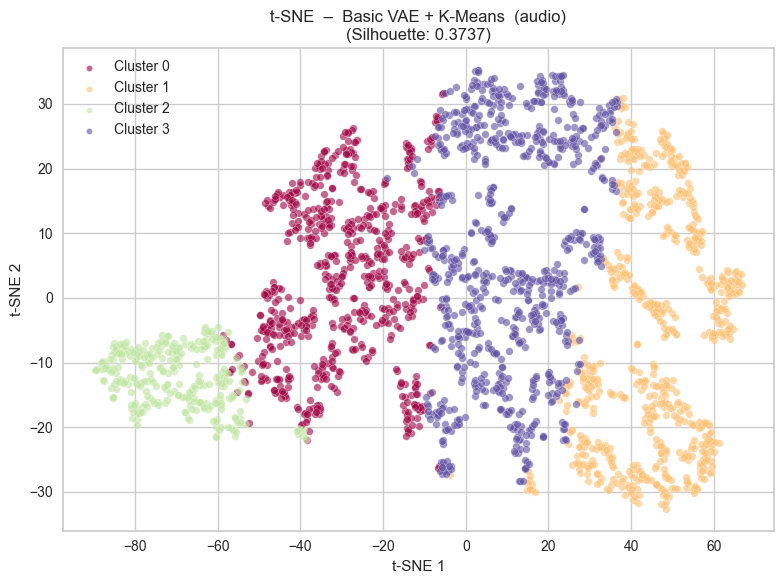

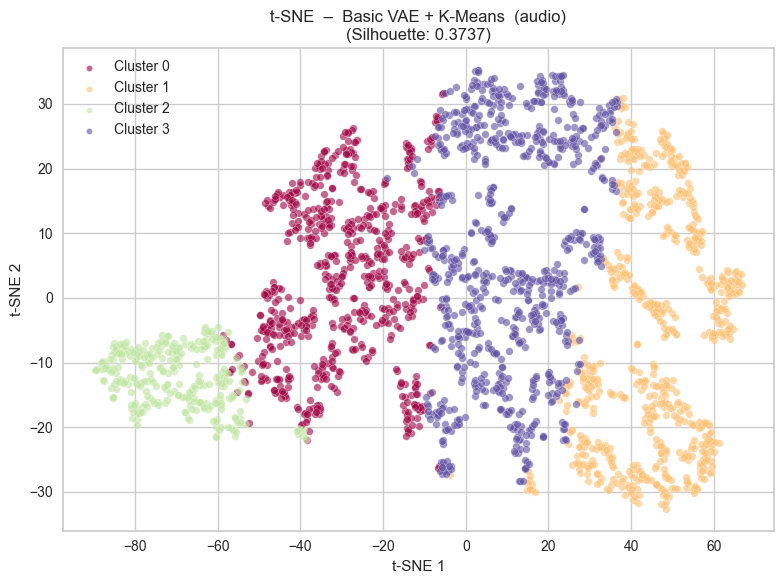

In [15]:
plot_tsne_clustering_comparison(
    vae_latents,
    [vae_kmeans.labels_, ],
    ["Basic VAE + K-Means  (audio)", ],
    scores=[silhouette_score(vae_latents, vae_kmeans.labels_),],
    save_path= TSNE_DIR / "easy_1_basic_vae.png"
)